In [ ]:
# %pip install "zenml[server]"
# ! zenml integration install sklearn -y


  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 4.4 MB/s  0:00:01 eta 0:00:01
Using cached click-8.2.1-py3-none-any.whl (102 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 5.6 MB/s  0:00:00 eta 0:00:01
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.6/525.6 kB 5.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: psutil━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/54 [sqlalchemy]
    Found existing installation: psutil 7.1.0━━━━━━━━━━━━━━━━━  5/54 [sqlalchemy]
    Uninstalling psutil-7.1.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/54 [sqlalchemy]
      Successf

In [ ]:
! rm -rf .zen
! zenml init # initialize zenml repo

Initializing the ZenML global configuration version to 0.95.1
⠋ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠼ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠇ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠹ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠧ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠇ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠏ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠹ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠸ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠴ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠧ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠇ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
Creating database tables
⠏ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠹ Initializing ZenML repository at /Users/tch/Desktop/MLOPS.
⠸ Initializing ZenML repository at /Users/tch/Desktop/MLOPS

In [ ]:
import numpy as np
from sklearn.base import ClassifierMixin
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

def train_test() -> None:
    digits = load_digits()
    data = digits.images.reshape((len(digits.images), -1)) #type: ignore
    X_train, X_test, y_train, y_test = train_test_split(
        data, digits.target, test_size=0.2, shuffle=False#type: ignore
    )

    model = SVC(gamma=0.001)
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print("test accuracy: {}".format(test_acc))

train_test()


test accuracy: 0.9583333333333334


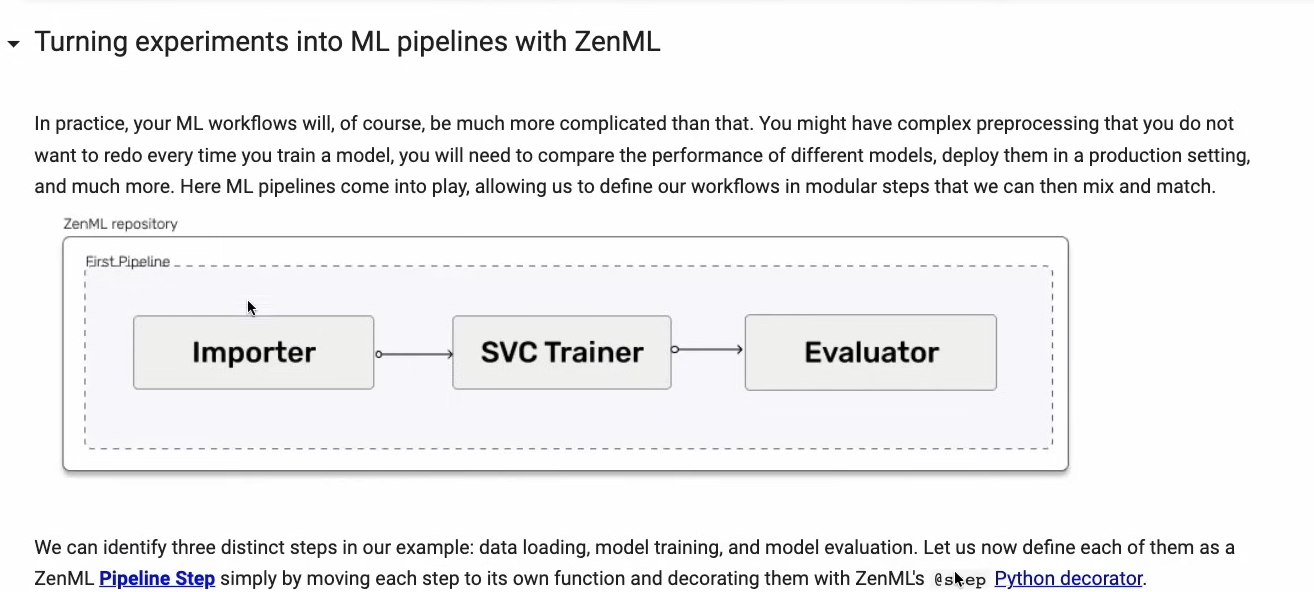


In [12]:
from zenml import step
from typing_extensions import Annotated
import pandas as pd
from typing import Tuple

@step
def importer()-> Tuple[
        Annotated[np.ndarray, "X_train"],
        Annotated[np.ndarray, "y_train"],
        Annotated[np.ndarray, "X_test"],
        Annotated[np.ndarray, "y_test"],
    ]:

    digits = load_digits()
    data = digits.images.reshape((len(digits.images), -1))#type: ignore
    X_train, X_test, y_train, y_test = train_test_split(
        data, digits.target, test_size=0.2, shuffle=False#type: ignore
        )
    return X_train, y_train, X_test, y_test


@step
def svc_trainer(
    X_train: np.ndarray,
    y_train: np.ndarray
)-> ClassifierMixin:
    model = SVC(gamma = 0.001)
    model.fit(X_train, y_train)

    return model


@step
def evaluator(X_test: np.ndarray,
            y_test: np.ndarray,
            model: ClassifierMixin) -> float:
    test_acc = float(model.score(X_test, y_test))
    print(f"test_accurcay: {test_acc}")
    return test_acc

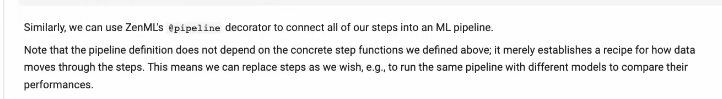

In [15]:
from zenml import pipeline

@pipeline
def digits_pipeline():
    X_train, y_train, X_test, y_test = importer()
    model = svc_trainer(X_train = X_train, y_train = y_train)
    evaluator(X_test = X_test, y_test  = y_test, model = model)

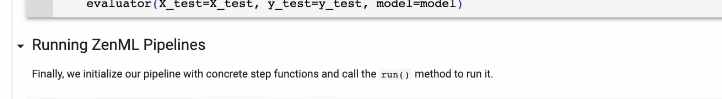

In [16]:
digits_svc_pipeline = digits_pipeline()

Initiating a new run for the pipeline: digits_pipeline.
Using user: default
Using stack: default
  artifact_store: default
  deployer: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Using cached version of step importer.
Step svc_trainer has started.
Step svc_trainer has finished in 0.281s.
Step evaluator has started.
test_accurcay: 0.9583333333333334
Step evaluator has finished in 0.443s.
Pipeline run has finished in 1.171s.
